# Ekstraksi Landmark BISINDO (Alfabet & Angka)

Notebook ini melakukan:
1. Eksplorasi dataset mentah (jumlah sample per kelas pada folder `Data/`)
2. Ekstraksi 21 koordinat landmark (x, y, z) per tangan menggunakan **MediaPipe HandLandmarker**
3. Normalisasi koordinat relatif terhadap wrist ($x_0, y_0, z_0$) dan scaling invariant
4. Menyimpan dataset tabular (63 fitur + label) ke `data/landmarks_bisindo.csv`

In [1]:
import os
import urllib.request
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

MODEL_PATH = '../hand_landmarker.task' if os.path.exists('../hand_landmarker.task') else 'hand_landmarker.task'
if not os.path.exists(MODEL_PATH):
    MODEL_URL = 'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task'
    print('Downloading hand_landmarker.task...')
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print('Model downloaded.')

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1, min_hand_detection_confidence=0.5)
hands_detector = vision.HandLandmarker.create_from_options(options)
print(f"MediaPipe version: {mp.__version__}")

MediaPipe version: 1.0.1


## 1. Eksplorasi Struktur Dataset

Total kelas terdeteksi: 35
Total seluruh gambar: 20626
Kelas  Jumlah Gambar
    0           1000
    1           1000
    2           1000
    3           1000
    4           1000
    5           1000
    6           1000
    7           1000
    8           1000
    9           1000
    A            438
    B            439
    C            429
    D            435
    E            441
    F            447
    G            450
    H            435
    I            450
    J            450
    K            435
    L            447
    M            444
    N            438
    O            447
    P            447
    Q            435
    R            438
    S            429
    T            450
    U            444
    V            447
    W            450
    X            444
    Y             17


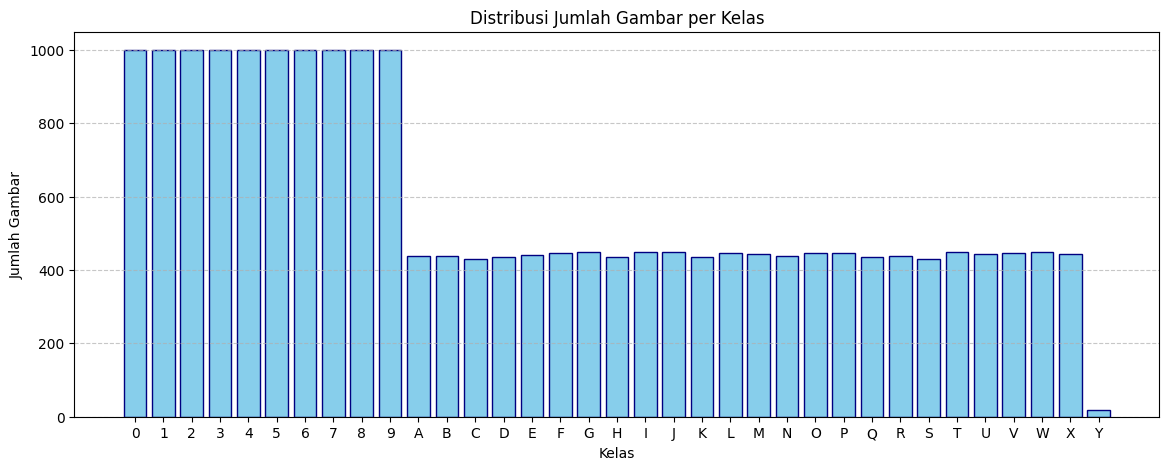

In [2]:
DATA_DIR = '../Data'
if not os.path.exists(DATA_DIR):
    DATA_DIR = 'Data'

class_counts = {}
image_paths_by_class = {}

for root, dirs, files in os.walk(DATA_DIR):
    valid_images = [os.path.join(root, f) for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if valid_images:
        class_name = os.path.basename(root)
        class_counts[class_name] = len(valid_images)
        image_paths_by_class[class_name] = valid_images

print(f"Total kelas terdeteksi: {len(class_counts)}")
print(f"Total seluruh gambar: {sum(class_counts.values())}")

df_counts = pd.DataFrame(list(class_counts.items()), columns=['Kelas', 'Jumlah Gambar']).sort_values('Kelas')
print(df_counts.to_string(index=False))

plt.figure(figsize=(14, 5))
plt.bar(df_counts['Kelas'], df_counts['Jumlah Gambar'], color='skyblue', edgecolor='navy')
plt.title('Distribusi Jumlah Gambar per Kelas')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 2. Definisi Fungsi Ekstraksi & Normalisasi Landmark

- **21 Titik Landmark** (x, y, z) = 63 fitur numerik.
- **Normalisasi Wrist**: $x_i' = x_i - x_0$, $y_i' = y_i - y_0$, $z_i' = z_i - z_0$
- **Normalisasi Skala**: dibagi dengan nilai absolut maksimum agar ukuran tangan / jarak kamera seragam.

In [3]:
def extract_and_normalize_landmarks(hand_landmarks):
    """
    Mengambil 21 titik landmark, mentranslasikan origin ke wrist (point 0),
    lalu melakukan scale normalization (dibagi max absolute value).
    """
    coords = []
    for lm in hand_landmarks:
        coords.append([lm.x, lm.y, lm.z])
    coords = np.array(coords)  # Shape: (21, 3)
    
    # 1. Translasi relatif ke wrist (landmark index 0)
    wrist = coords[0]
    coords_relative = coords - wrist
    
    # 2. Scale normalization
    max_val = np.max(np.abs(coords_relative))
    if max_val > 0:
        coords_normalized = coords_relative / max_val
    else:
        coords_normalized = coords_relative
        
    # Flatten menjadi 63 fitur
    return coords_normalized.flatten().tolist()

## 3. Visualisasi Landmark pada Sample Gambar

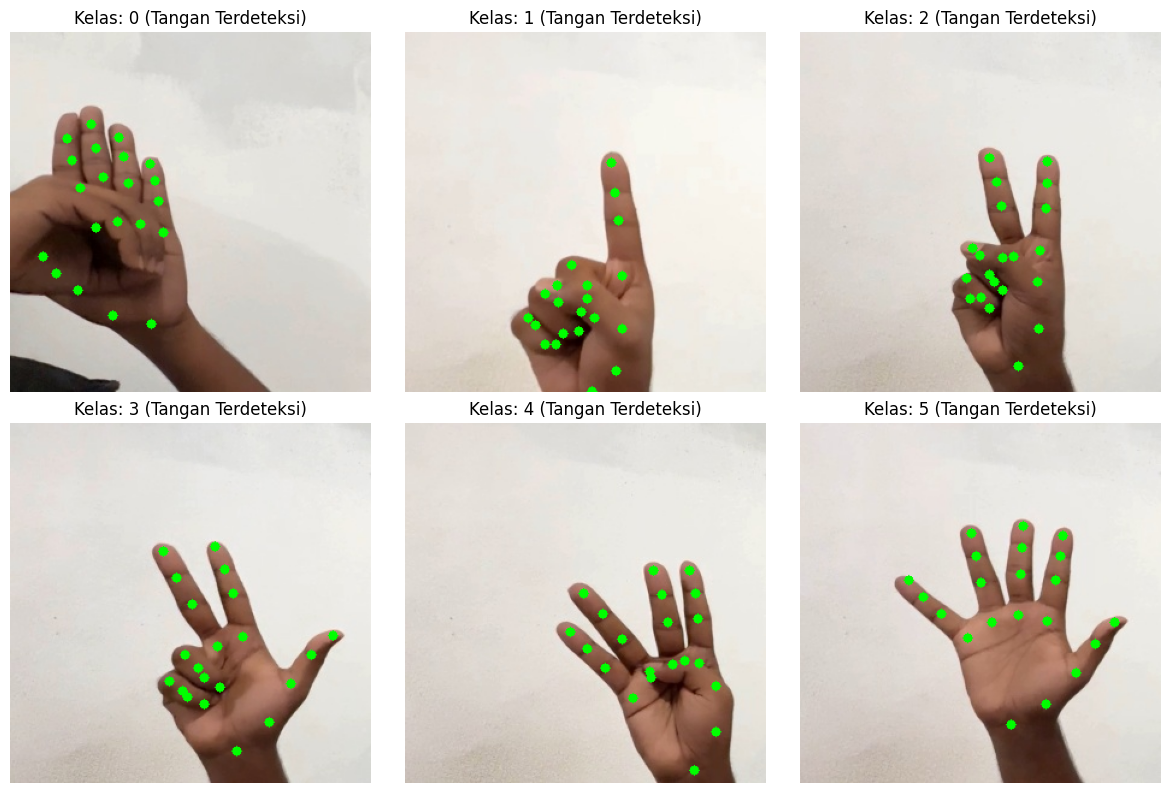

In [4]:
# Ambil beberapa sample kelas untuk divisualisasikan
sample_classes = list(class_counts.keys())[:6]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, cls in enumerate(sample_classes):
    sample_img_path = image_paths_by_class[cls][0]
    mp_image = mp.Image.create_from_file(sample_img_path)
    results = hands_detector.detect(mp_image)
    img_rgb = mp_image.numpy_view().copy()
    if results.hand_landmarks and len(results.hand_landmarks) > 0:
        h, w, _ = img_rgb.shape
        for lm in results.hand_landmarks[0]:
            cx, cy = int(lm.x * w), int(lm.y * h)
            cv2.circle(img_rgb, (cx, cy), 4, (0, 255, 0), -1)
        axes[idx].set_title(f"Kelas: {cls} (Tangan Terdeteksi)")
    else:
        axes[idx].set_title(f"Kelas: {cls} (Tidak Terdeteksi)")
    axes[idx].imshow(img_rgb)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 4. Ekstraksi Landmark untuk Seluruh Dataset

In [5]:
data_rows = []
stats = {'success': 0, 'failed': 0, 'per_class_success': {}, 'per_class_failed': {}}

for cls in class_counts.keys():
    stats['per_class_success'][cls] = 0
    stats['per_class_failed'][cls] = 0

for cls, img_paths in image_paths_by_class.items():
    print(f"Memproses kelas: {cls} ({len(img_paths)} gambar)...")
    for p in tqdm(img_paths, desc=cls):
        try:
            mp_image = mp.Image.create_from_file(p)
            results = hands_detector.detect(mp_image)
            if results.hand_landmarks and len(results.hand_landmarks) > 0:
                landmarks_features = extract_and_normalize_landmarks(results.hand_landmarks[0])
                data_rows.append(landmarks_features + [cls])
                stats['success'] += 1
                stats['per_class_success'][cls] += 1
            else:
                stats['failed'] += 1
                stats['per_class_failed'][cls] += 1
        except Exception:
            stats['failed'] += 1
            stats['per_class_failed'][cls] += 1

print(f"\nEkstraksi selesai:")
print(f"Total Berhasil: {stats['success']}")
print(f"Total Gagal/Dilewati: {stats['failed']}")
print(f"Detection Rate: {stats['success'] / (stats['success'] + stats['failed']) * 100:.2f}%")

Memproses kelas: 0 (1000 gambar)...


0: 100%|██████████| 1000/1000 [00:28<00:00, 35.08it/s]


Memproses kelas: 1 (1000 gambar)...


1: 100%|██████████| 1000/1000 [00:38<00:00, 25.73it/s]


Memproses kelas: 2 (1000 gambar)...


...

Memproses kelas: X (444 gambar)...


X: 100%|██████████| 444/444 [00:13<00:00, 33.64it/s]


Memproses kelas: Y (17 gambar)...


Y: 100%|██████████| 17/17 [00:00<00:00, 33.24it/s]


Ekstraksi selesai:
Total Berhasil: 18502
Total Gagal/Dilewati: 2124
Detection Rate: 89.70%


## 5. Simpan Hasil Ekstraksi ke CSV

In [6]:
# Buat nama kolom: x_0, y_0, z_0 ... x_20, y_20, z_20, label
feature_columns = []
for i in range(21):
    feature_columns.extend([f"x_{i}", f"y_{i}", f"z_{i}"])
columns = feature_columns + ["label"]

df_landmarks = pd.DataFrame(data_rows, columns=columns)

os.makedirs('../data', exist_ok=True)
os.makedirs('data', exist_ok=True)
output_csv = 'data/landmarks_bisindo.csv'
df_landmarks.to_csv(output_csv, index=False)
print(f"Dataset landmark berhasil disimpan ke {output_csv}")
print(f"Shape dataset: {df_landmarks.shape}")
display(df_landmarks.head())

Dataset landmark berhasil disimpan ke data/landmarks_bisindo.csv
Shape dataset: (18502, 64)


,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,z_2,x_3,...,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20,label
0,0.0,0.0,0.0,-0.193309,-0.041921,-0.083931,-0.366021,-0.166058,-0.130076,-0.475472,...,0.036274,-0.617256,-0.183173,0.017587,-0.718039,-0.221485,-0.005772,-0.802046,-0.244649,0
1,0.0,0.0,0.0,0.310487,0.214919,-0.004747,0.595298,0.273700,0.012833,0.804865,...,0.706439,-0.229688,-0.074571,0.795906,-0.140760,-0.111689,0.841795,-0.052069,-0.133923,0
2,0.0,0.0,0.0,0.301624,0.197207,-0.021062,0.590410,0.255909,-0.011869,0.799498,...,0.695151,-0.252845,-0.078202,0.789651,-0.168918,-0.126816,0.835595,-0.085619,-0.157005,0
3,0.0,0.0,0.0,-0.217812,-0.051518,-0.070208,-0.385650,-0.185830,-0.107451,-0.469460,...,0.036597,-0.584753,-0.186149,0.013565,-0.686300,-0.221929,-0.012571,-0.771809,-0.242617,0
4,0.0,0.0,0.0,0.317865,0.188971,0.021342,0.599104,0.214712,0.046171,0.794611,...,0.742339,-0.289184,-0.164362,0.837000,-0.172259,-0.220605,0.875682,-0.043144,-0.253438,0


## 6. Verifikasi Distribusi Sample Hasil Ekstraksi

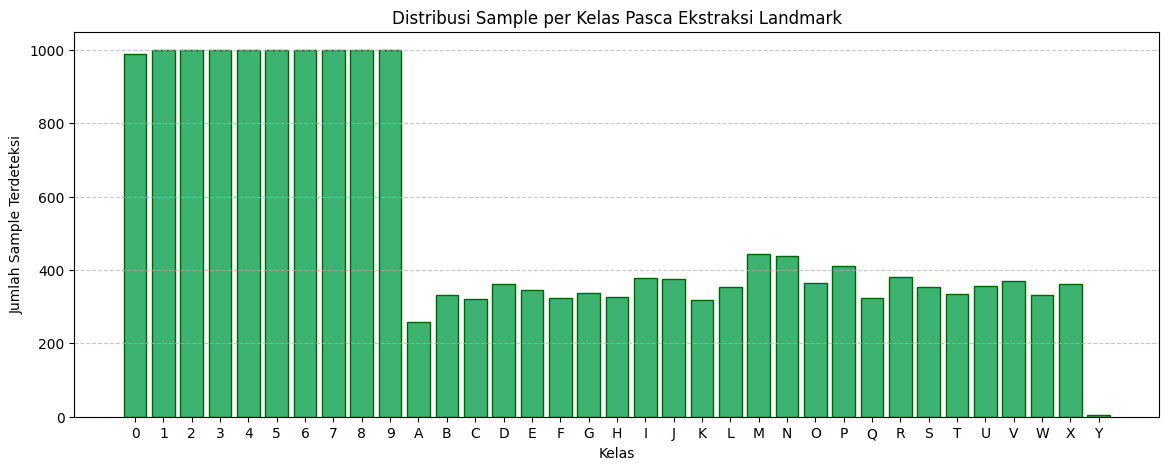

In [7]:
plt.figure(figsize=(14, 5))
extracted_counts = df_landmarks['label'].value_counts().sort_index()
plt.bar(extracted_counts.index, extracted_counts.values, color='mediumseagreen', edgecolor='darkgreen')
plt.title('Distribusi Sample per Kelas Pasca Ekstraksi Landmark')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sample Terdeteksi')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()